## Code accompanying slides for CNN

In [ ]:
! pip install -q gdown
! pip install -q colorama # for color-based texts
! pip install -q torchviz # for visualizing graphs
! pip install -q torchview # for visualizing graphs
! pip install -q graphviz # for visualizing graphs
! pip install -q torchsummary # for finding the number of parameters of a model

In [ ]:
# General imports
import os
import cv2
import glob
import numpy as np
import random
from tqdm import tqdm
from pathlib import Path
from colorama import Fore, Style
from collections import Counter, defaultdict

# Model based imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Viz-based imports
from torchsummary import summary
from torchview import draw_graph
import graphviz
graphviz.set_jupyter_format('png')
import seaborn as sns
import matplotlib.pyplot as plt

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


SEED = 42
random.seed(SEED)
np.random.seed(SEED)

Using device: cpu


In [ ]:
class Example1FCL(nn.Module):
    def __init__(self, input_size=9, output_size=4):
        super(Example1FCL, self).__init__()
        self.fc1 = nn.Linear(input_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        return x

In [ ]:
model_FCL = Example1FCL(input_size=9, output_size=4)
model_FCL = model_FCL.to(device)
print(model_FCL)

Example1FCL(
  (fc1): Linear(in_features=9, out_features=4, bias=True)
)


In [ ]:
# Create sample input (batch_size=1, features=9)
# sample_input = torch.randn(1, 9)
summary(model_FCL, input_size=(1,9))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [-1, 1, 4]              40
Total params: 40
Trainable params: 40
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


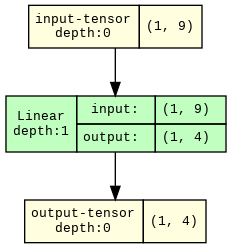

In [ ]:
model_graph1 = draw_graph(model_FCL, input_size=[(1, 9)],  expand_nested=True)
model_graph1.visual_graph.render(format='png')
model_graph1.visual_graph

In [ ]:
fcl_model = Example1FCL(input_size=9, output_size=4)
fcl_params = sum(p.numel() for p in fcl_model.parameters())
print(f"FCL Parameters: {fcl_params}")


FCL Parameters: 40


In [ ]:
class Example1CNN(nn.Module):
    def __init__(self):
        super(Example1CNN, self).__init__()
        # 1 input channel, 1 output channel, kernel_size=4
        # Parameters: (1 * 4 + 1) * 1 = 5 total
        self.c1 = nn.Conv1d(1, 1, kernel_size=4)

    def forward(self, x):
        x = self.c1(x)
        return x

In [ ]:
# Test the model
model_CNN = Example1CNN()
print(f"Total parameters: {sum(p.numel() for p in model_CNN.parameters())}")

Total parameters: 5


In [ ]:
# For input (1, 9), reshape to (1, 1, 9) for Conv1d
# TorchSummary input size: (channels, sequence_length)
summary(model_CNN, input_size=(1, 9))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1                 [-1, 1, 6]               5
Total params: 5
Trainable params: 5
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


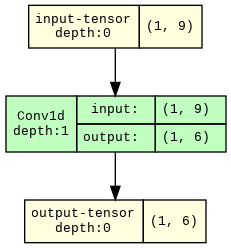

In [ ]:
# draw the computational graph of the model
model_graph1 = draw_graph(model_CNN, input_size=[(1, 9)],  expand_nested=True)
model_graph1.visual_graph.render(format='png')
model_graph1.visual_graph

In [ ]:
input_vol = torch.randn(1, 1, 1, 3072)
kernel = torch.randn(1, 10, 1, 3072)
# the multiplication broadcasts to shape (1, 10, 1, 3072) and
# you need to sum along the feature dimension (last dimension) to
# get the convolution result of shape (1, 10, 1, 1).
output = torch.sum(input_vol * kernel, dim=-1, keepdim=True)
print(output.shape)

torch.Size([1, 10, 1, 1])


In [ ]:
import torch

in_channels = 3072
out_channels = 10
kernel_size = 1
bias = True

params = out_channels * in_channels * kernel_size * kernel_size + (out_channels if bias else 0)
print(params)

30730


In [ ]:
import torch

input_vol = torch.randn(1, 3, 32, 32)
kernel = torch.randn(1, 3, 5, 5)
output = torch.conv2d(input_vol, kernel)

params = 1 * 3 * 5 * 5 + 1
print(f"Output shape: {output.shape}, Parameters: {params}")

Output shape: torch.Size([1, 1, 28, 28]), Parameters: 76


In [ ]:
class ExampleCNN_Slide1(nn.Module):
    def __init__(self):
        super(ExampleCNN_Slide1, self).__init__()
        self.c1 = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=5, stride=1, padding=0)

    def forward(self, x):
        x = self.c1(x)
        return x

In [ ]:
# Test the model
model_CNN_slide1 = ExampleCNN_Slide1()
print(f"Total parameters: {sum(p.numel() for p in model_CNN_slide1.parameters())}")

Total parameters: 76


In [ ]:
summary(model_CNN_slide1, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 1, 28, 28]              76
Total params: 76
Trainable params: 76
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.01
Params size (MB): 0.00
Estimated Total Size (MB): 0.02
----------------------------------------------------------------


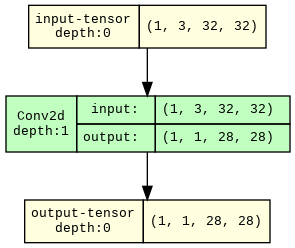

In [ ]:
# draw the computational graph of the model
model_graph1 = draw_graph(model_CNN_slide1, input_size=[(1, 3, 32, 32)],  expand_nested=True)
model_graph1.visual_graph.render(format='png')
model_graph1.visual_graph

In [ ]:
class ExampleCNN_Slide2(nn.Module):
    def __init__(self):
        super(ExampleCNN_Slide2, self).__init__()
        self.c1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=0)

    def forward(self, x):
        x = self.c1(x)
        return x

In [ ]:
# Test the model
model_ExampleCNN_Slide2 = ExampleCNN_Slide2()
print(f"Total parameters: {sum(p.numel() for p in model_ExampleCNN_Slide2.parameters())}")

Total parameters: 456


In [ ]:
summary(model_ExampleCNN_Slide2, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             456
Total params: 456
Trainable params: 456
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.04
Params size (MB): 0.00
Estimated Total Size (MB): 0.05
----------------------------------------------------------------


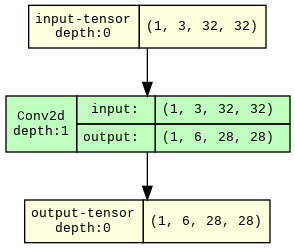

In [ ]:
# draw the computational graph of the model
model_graph1 = draw_graph(model_ExampleCNN_Slide2, input_size=[(1, 3, 32, 32)],  expand_nested=True)
model_graph1.visual_graph.render(format='png')
model_graph1.visual_graph

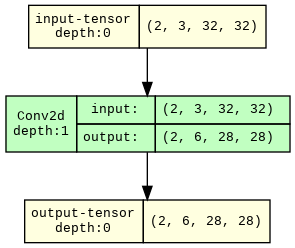

In [ ]:
# draw the computational graph of the model
model_graph1 = draw_graph(model_ExampleCNN_Slide2, input_size=[(2, 3, 32, 32)],  expand_nested=True)
model_graph1.visual_graph.render(format='png')
model_graph1.visual_graph

In [ ]:
class ExampleCNN_Slide3(nn.Module):
    def __init__(self):
        super(ExampleCNN_Slide3, self).__init__()
        self.c1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=0)
        self.c2 = nn.Conv2d(in_channels=6, out_channels=10, kernel_size=5, stride=1, padding=0)

    def forward(self, x):
        x = self.c1(x)
        x = self.c2(x)
        return x

In [ ]:
# Test the model
model_ExampleCNN_Slide3 = ExampleCNN_Slide3()
# print(f"Total parameters: {sum(p.numel() for p in ExampleCNN_Slide2.parameters())}")
summary(model_ExampleCNN_Slide3, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             456
            Conv2d-2           [-1, 10, 24, 24]           1,510
Total params: 1,966
Trainable params: 1,966
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.08
Params size (MB): 0.01
Estimated Total Size (MB): 0.10
----------------------------------------------------------------


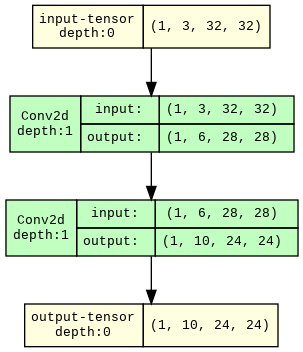

In [ ]:
# draw the computational graph of the model
model_graph1 = draw_graph(model_ExampleCNN_Slide3, input_size=[(1, 3, 32, 32)],  expand_nested=True)
model_graph1.visual_graph.render(format='png')
model_graph1.visual_graph

In [ ]:
class ExampleCNN_Slide4(nn.Module):
    def __init__(self):
        super(ExampleCNN_Slide4, self).__init__()
        self.c1 = nn.Conv2d(in_channels=64, out_channels=32, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        x = self.c1(x)
        return x

In [ ]:
# Test the model
model_ExampleCNN_Slide4 = ExampleCNN_Slide4()
# print(f"Total parameters: {sum(p.numel() for p in ExampleCNN_Slide2.parameters())}")
summary(model_ExampleCNN_Slide4, input_size=(64, 56, 56))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 56, 56]           2,080
Total params: 2,080
Trainable params: 2,080
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.77
Forward/backward pass size (MB): 0.77
Params size (MB): 0.01
Estimated Total Size (MB): 1.54
----------------------------------------------------------------


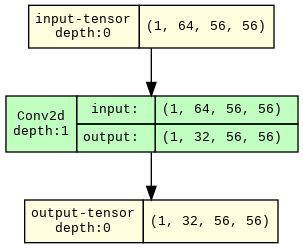

In [ ]:
# draw the computational graph of the model
model_graph1 = draw_graph(model_ExampleCNN_Slide4, input_size=[(1,64, 56, 56)],  expand_nested=True)
model_graph1.visual_graph.render(format='png')
model_graph1.visual_graph

In [ ]:
class Example_ffcnn(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3,
                               out_channels=3,kernel_size=3,
                               stride=2, padding=1)
        self.conv2 = nn.Conv2d(in_channels=3,
                               out_channels=3, kernel_size=3,
                               stride=1, padding=3)
        self.bn2d = nn.BatchNorm2d(3)
        self.maxpool = nn.MaxPool2d(2)
        self.flatten = torch.nn.Flatten()
        self.fc1 = nn.Linear(48, 10)
        self.bn1d = nn.BatchNorm1d(10)
        self.out = nn.Linear(10, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn2d(x)
        x = self.maxpool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.bn1d(x)
        x = self.out(x)
        x = self.sigmoid(x)
        return x

In [ ]:
model = Example_ffcnn()
summary(model, input_size=(3,7,7))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1              [-1, 3, 4, 4]              84
            Conv2d-2              [-1, 3, 8, 8]              84
       BatchNorm2d-3              [-1, 3, 8, 8]               6
         MaxPool2d-4              [-1, 3, 4, 4]               0
           Flatten-5                   [-1, 48]               0
            Linear-6                   [-1, 10]             490
       BatchNorm1d-7                   [-1, 10]              20
            Linear-8                    [-1, 1]              11
           Sigmoid-9                    [-1, 1]               0
Total params: 695
Trainable params: 695
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.01
---------------------------------------------------

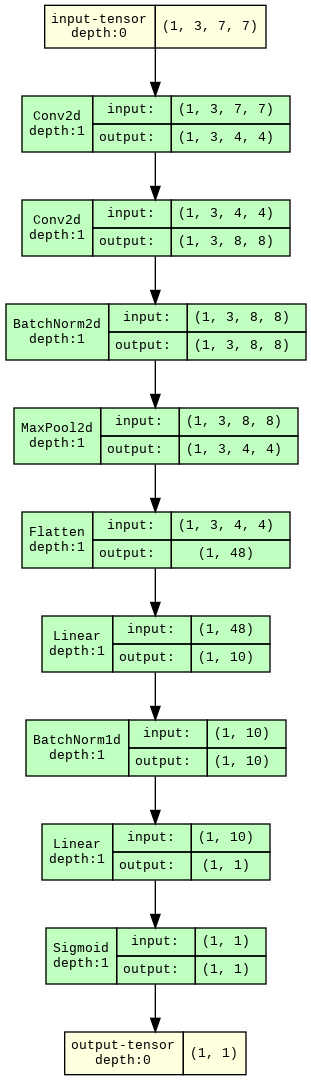

In [ ]:
model = Example_ffcnn()
mg1 = draw_graph(model, input_size=(1,3,7,7), expand_nested=True)
mg1.visual_graph.render(format='png')
mg1.visual_graph

In [ ]:
! wget "https://jimut123.github.io/blogs/IITB_OLD/old/main_building_1958.jpg"

--2025-08-27 08:12:49--  https://jimut123.github.io/blogs/IITB_OLD/old/main_building_1958.jpg
Resolving jimut123.github.io (jimut123.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to jimut123.github.io (jimut123.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 602677 (589K) [image/jpeg]
Saving to: ‘main_building_1958.jpg’

main_building_1958. 100%[===================>] 588.55K  2.63MB/s    in 0.2s    

2025-08-27 08:12:50 (2.63 MB/s) - ‘main_building_1958.jpg’ saved [602677/602677]



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
img_mb = cv2.imread("main_building_1958.jpg",cv2.IMREAD_UNCHANGED)
print("shape of image = ",img_mb.shape)
print("first 10x10 pixels from top left = \n",img_mb[:10,:10])

shape of image =  (1409, 2835)
first 10x10 pixels from top left = 
 [[174 173 171 170 170 172 173 174 177 178]
 [174 173 172 171 171 172 173 174 178 179]
 [175 174 173 172 172 173 174 174 178 179]
 [176 176 175 175 175 175 175 175 179 180]
 [179 179 179 179 178 177 177 176 180 181]
 [182 183 183 183 182 181 180 179 181 182]
 [185 186 187 187 186 184 182 181 181 182]
 [187 188 189 189 188 186 184 182 182 183]
 [188 188 188 188 188 188 188 188 181 183]
 [187 187 187 188 188 189 189 189 183 184]]


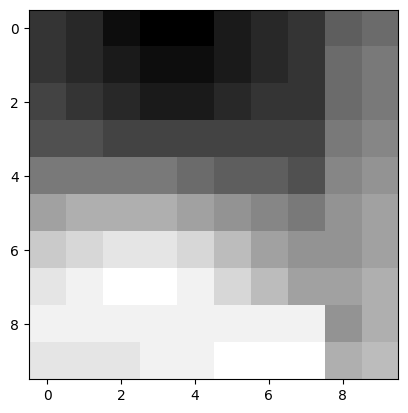

In [ ]:
plt.imshow(img_mb[:10,:10],cmap='gray')

In [ ]:
! wget "https://jimut123.github.io/img/gallery/this_side_sameer_hills.jpg"

--2025-08-27 08:29:16--  https://jimut123.github.io/img/gallery/this_side_sameer_hills.jpg
Resolving jimut123.github.io (jimut123.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to jimut123.github.io (jimut123.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5748752 (5.5M) [image/jpeg]
Saving to: ‘this_side_sameer_hills.jpg’

this_side_sameer_hi 100%[===================>]   5.48M  14.0MB/s    in 0.4s    

2025-08-27 08:29:18 (14.0 MB/s) - ‘this_side_sameer_hills.jpg’ saved [5748752/5748752]



In [ ]:
img_sh = cv2.imread("this_side_sameer_hills.jpg",cv2.IMREAD_UNCHANGED)
print("shape of image = \n",img_sh.shape)
print("first 5x5 pixels \n from top left = \n",img_sh[:5,:5,:])

shape of image = 
 (2088, 4640, 3)
first 5x5 pixels 
 from top left = 
 [[[224 198 128]
  [226 200 130]
  [230 204 134]
  [226 200 130]
  [225 199 129]]

 [[230 204 134]
  [225 199 129]
  [226 200 130]
  [223 197 127]
  [226 200 130]]

 [[232 207 137]
  [227 202 132]
  [230 205 135]
  [228 203 133]
  [232 206 136]]

 [[224 199 129]
  [223 198 128]
  [227 202 132]
  [227 201 131]
  [228 202 132]]

 [[222 197 127]
  [225 200 130]
  [228 202 132]
  [228 202 132]
  [228 202 132]]]
